# Statistics US13 to US18 and US28 to US31

## Imports


In [1]:
import os
import statistics as st
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

DATASET_DECLARATIONS = 'dataset1_declarations.csv'
DATASET_HOLDINGS = 'dataset2_holdings.csv'


## US13 - Analysis by type, role and institution

In [2]:
df = pd.read_csv(DATASET_DECLARATIONS, dtype=str, keep_default_na=False)
for f in ['declaration_id','agent_id','role','institution','declaration_type','declaration_date']:
    if f in df.columns:
        df[f] = df[f].astype(str).str.strip()
print('Total declarations:', len(df))
df.head()


Total declarations: 13395


,agent_id,role,declaration_type,declaration_date,declaration_id,institution,gross_salary,side_income_consulting,side_income_board_memberships,assets_in_real_estate,assets_in_vehicles,assets_in_stocks
0,A00001,MP,initial,2024-05-02 15:56:35,D000000,Parliament,59908.9363269016,9110.079681067367,34447.6273674199,7828.784402128915,19794.715427272135,16802.708297322108
1,A00001,MP,regular,2025-01-15 00:00:00,D000001,Parliament,72577.36161677462,31565.082510881977,14655.365341489232,447.7719282665942,937.7508333147579,25027.953104492994
2,A00001,MP,regular,2026-01-15 00:00:00,D000002,Parliament,61227.440378213476,26782.41004776108,9141.892217124767,16945.613880322635,4244.49395835199,29924.280475238847
3,A00002,MP,initial,2019-10-19 21:17:16,D000003,Parliament,58516.65520213286,51926.13193062236,22923.8179776875,5665.232082242071,11390.513686394026,31017.28844744206
4,A00002,MP,regular,2020-01-15 00:00:00,D000004,Parliament,73786.14724481653,1208.370991861059,17842.785255315517,36802.95007837799,63901.049798724496,38416.38532156148


By type:
  exceptional 860
  initial 2364
  regular 10171


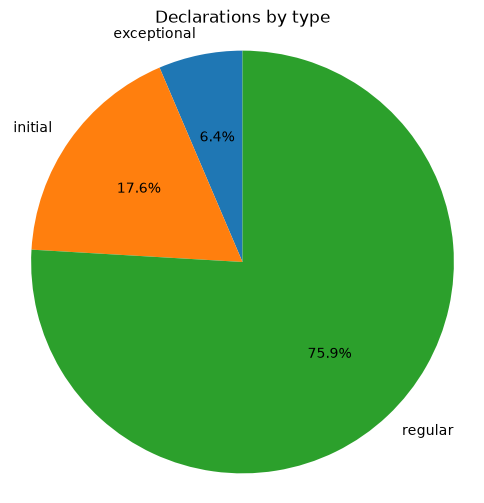

In [3]:
type_counts = df['declaration_type'].value_counts().sort_index()
print('By type:')
for k,v in type_counts.items(): print(' ', k, v)

fig, ax = plt.subplots(figsize=(6,6))
ax.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', startangle=90)
ax.axis('equal')
ax.set_title('Declarations by type')
plt.show()


By role:
  Advisor 1572
  Judge 8912
  MP 2360
  Minister 175
  State Secretary 376
By institution:
  Courts 8912
  Government 2123
  Parliament 2360


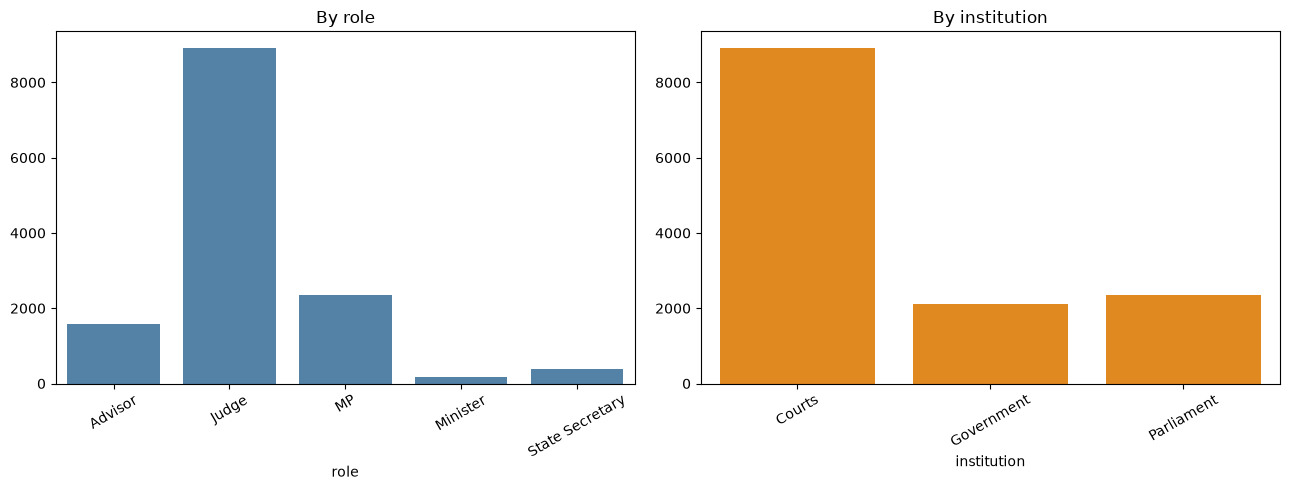

In [4]:
role_counts = df['role'].value_counts().sort_index()
inst_counts = df['institution'].value_counts().sort_index()
print('By role:')
for k,v in role_counts.items(): print(' ', k, v)
print('By institution:')
for k,v in inst_counts.items(): print(' ', k, v)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13,5))
sns.barplot(x=role_counts.index, y=role_counts.values, color='steelblue', ax=ax1)
ax1.set_title('By role'); ax1.tick_params(axis='x', rotation=30)
sns.barplot(x=inst_counts.index, y=inst_counts.values, color='darkorange', ax=ax2)
ax2.set_title('By institution'); ax2.tick_params(axis='x', rotation=30)
fig.tight_layout()
plt.show()


## US14 - Statistical measures of income and assets

In [5]:
import math
df14 = pd.read_csv(DATASET_DECLARATIONS)
df14 = df14.sort_values('declaration_date').drop_duplicates(subset='agent_id', keep='last')
df14['total_income'] = df14['gross_salary'] + df14['side_income_consulting'] + df14['side_income_board_memberships']
df14['total_assets'] = df14['assets_in_real_estate'] + df14['assets_in_vehicles'] + df14['assets_in_stocks']
print('Agents:', len(df14))


Agents: 2364


In [6]:
def sturges_classes(n):
    return int(1 + 3.3 * math.log10(n))

def frequency_table(data):
    n = len(data)
    c = sturges_classes(n)
    counts, edges = np.histogram(data, bins=c)
    rows = []
    cum_abs = 0
    for i in range(c):
        n_i = int(counts[i])
        cum_abs += n_i
        rows.append({
            'class':    f'[{edges[i]:,.2f}, {edges[i+1]:,.2f}' + (']' if i == c - 1 else '['),
            'midpoint': (edges[i] + edges[i+1]) / 2,
            'abs_freq': n_i,
            'rel_freq': n_i / n,
            'cum_abs':  cum_abs,
            'cum_rel':  cum_abs / n,
        })
    return pd.DataFrame(rows)

def modal_class(data):
    table = frequency_table(data)
    idx = table['abs_freq'].idxmax()
    return {
        'class':    table.loc[idx, 'class'],
        'midpoint': table.loc[idx, 'midpoint'],
        'abs_freq': table.loc[idx, 'abs_freq'],
        'rel_freq': table.loc[idx, 'rel_freq'],
    }


In [7]:
for var, label in [('total_income','Total Income'), ('total_assets','Total Assets')]:
    data = df14[var].dropna()
    modal = modal_class(data)
    print(label)
    print('  mean:', round(data.mean(), 2))
    print('  median:', round(data.median(), 2))
    print('  modal class:', modal['class'])
    print('  modal midpoint:', round(modal['midpoint'], 2), '(freq:', modal['abs_freq'], ')')
    print()


Total Income
  mean: 99881.31
  median: 95737.34
  modal class: [81,617.60, 101,040.13[
  modal midpoint: 91328.87 (freq: 636 )

Total Assets
  mean: 59372.53
  median: 53688.64
  modal class: [21,949.72, 42,126.98[
  modal midpoint: 32038.35 (freq: 603 )



In [8]:
for var, label in [('total_income','Total Income'), ('total_assets','Total Assets')]:
    data = df14[var].dropna()
    quartiles = st.quantiles(data.tolist(), n=4)
    deciles = st.quantiles(data.tolist(), n=10)
    percentiles = st.quantiles(data.tolist(), n=100)
    print(label)
    print('  q1:', round(quartiles[0], 2), ' q2:', round(quartiles[1], 2), ' q3:', round(quartiles[2], 2))
    print('  d1:', round(deciles[0], 2), ' d5:', round(deciles[4], 2), ' d9:', round(deciles[8], 2))
    print('  p10:', round(percentiles[9], 2), ' p25:', round(percentiles[24], 2), ' p75:', round(percentiles[74], 2), ' p90:', round(percentiles[89], 2))
    print()


Total Income
  q1: 77968.62  q2: 95737.34  q3: 117096.71
  d1: 62222.21  d5: 95737.34  d9: 141383.19
  p10: 62222.21  p25: 77968.62  p75: 117096.71  p90: 141383.19

Total Assets
  q1: 34064.72  q2: 53688.64  q3: 77580.02
  d1: 21815.28  d5: 53688.64  d9: 103072.17
  p10: 21815.28  p25: 34064.72  p75: 77580.02  p90: 103072.17



In [9]:
for var, label in [('total_income','Total Income'), ('total_assets','Total Assets')]:
    data = df14[var].dropna()
    q = st.quantiles(data.tolist(), n=4)
    print(label)
    print('  range:', round(data.max() - data.min(), 2))
    print('  iqr:', round(q[2] - q[0], 2))
    print('  variance:', round(data.var(), 2))
    print('  std:', round(data.std(), 2))
    print('  cv:', round(data.std() / abs(data.mean()), 4))
    print()


Total Income
  range: 233070.36
  iqr: 39128.08
  variance: 1008251948.73
  std: 31752.98
  cv: 0.3179

Total Assets
  range: 242127.11
  iqr: 43515.31
  variance: 1189391967.74
  std: 34487.56
  cv: 0.5809



In [10]:
for var, label in [('total_income','Total Income'), ('total_assets','Total Assets')]:
    data = df14[var].dropna()
    s = float(stats.skew(data, bias=False))
    k = float(stats.kurtosis(data, fisher=False))
    print(label)
    print('  skewness:', round(s, 4))
    print('  kurtosis:', round(k, 4))
    print()


Total Income
  skewness: 0.8056
  kurtosis: 4.0241

Total Assets
  skewness: 1.2561
  kurtosis: 5.6052



### Frequency table by classes (Sturges)

In [11]:
for var, label in [('total_income','Total Income'), ('total_assets','Total Assets')]:
    data = df14[var].dropna()
    print(label, '- frequency table (Sturges, k =', sturges_classes(len(data)), 'classes)')
    print(frequency_table(data).to_string(index=False))
    print()


Total Income - frequency table (Sturges, k = 12 classes)
                   class      midpoint  abs_freq  rel_freq  cum_abs  cum_rel
  [23,350.01, 42,772.54[  33061.275759        27  0.011421       27 0.011421
  [42,772.54, 62,195.07[  52483.805524       208  0.087986      235 0.099408
  [62,195.07, 81,617.60[  71906.335289       473  0.200085      708 0.299492
 [81,617.60, 101,040.13[  91328.865054       636  0.269036     1344 0.568528
[101,040.13, 120,462.66[ 110751.394819       492  0.208122     1836 0.776650
[120,462.66, 139,885.19[ 130173.924584       279  0.118020     2115 0.894670
[139,885.19, 159,307.72[ 149596.454348       133  0.056261     2248 0.950931
[159,307.72, 178,730.25[ 169018.984113        70  0.029611     2318 0.980541
[178,730.25, 198,152.78[ 188441.513878        25  0.010575     2343 0.991117
[198,152.78, 217,575.31[ 207864.043643        17  0.007191     2360 0.998308
[217,575.31, 236,997.84[ 227286.573408         3  0.001269     2363 0.999577
[236,997.84, 256,42

Total Income outliers: 55
Total Assets outliers: 63


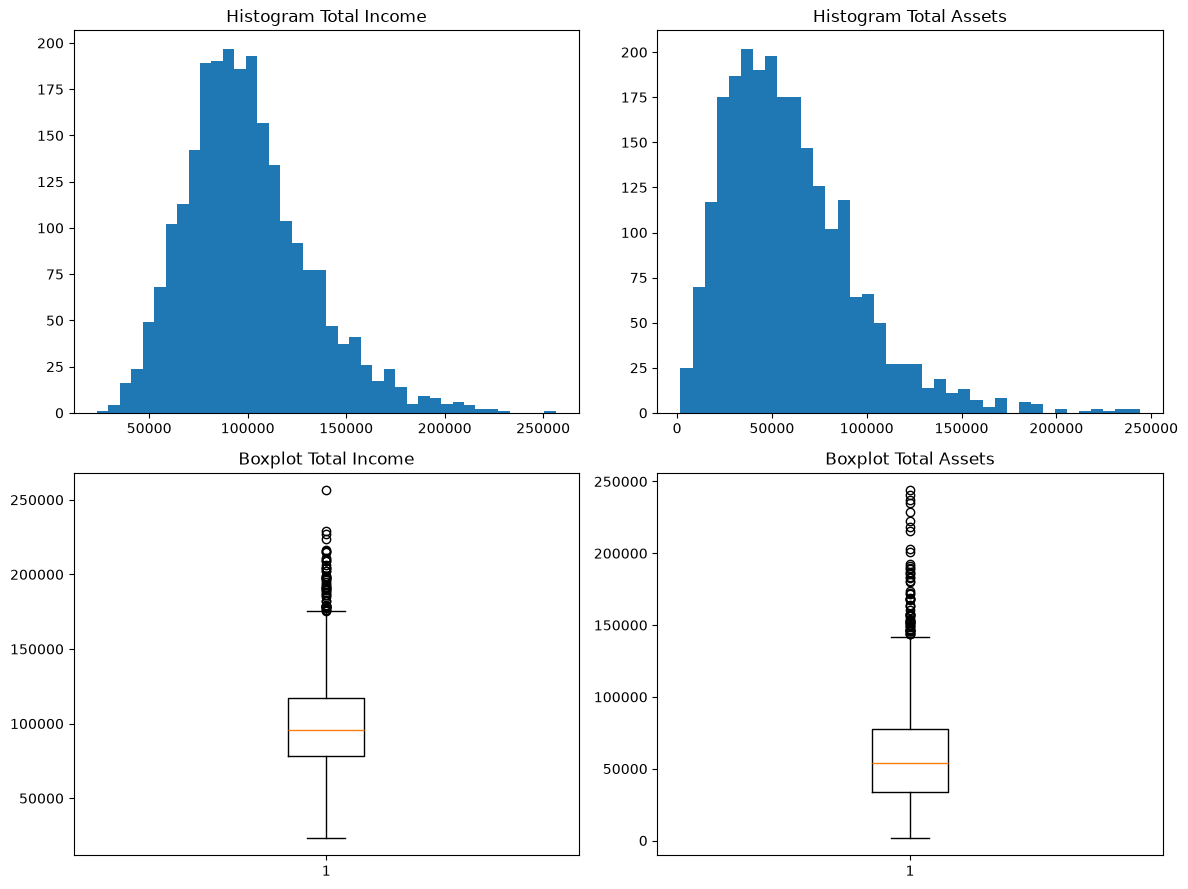

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
for col, (var, label) in enumerate([('total_income','Total Income'), ('total_assets','Total Assets')]):
    data = df14[var].dropna()
    axes[0, col].hist(data, bins='auto')
    axes[0, col].set_title('Histogram ' + label)
    axes[1, col].boxplot(data)
    axes[1, col].set_title('Boxplot ' + label)
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    outliers = data[(data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)]
    print(label, 'outliers:', len(outliers))
fig.tight_layout()
plt.show()


## US15 - Asset evolution of a political agent

In [13]:
agent_id = 'A00001'
agent_df = pd.read_csv(DATASET_DECLARATIONS)
agent_df = agent_df[agent_df['agent_id'].astype(str).str.strip() == agent_id].sort_values('declaration_date')
print(agent_id, 'declarations:', len(agent_df))
agent_df.head()


A00001 declarations: 3


,agent_id,role,declaration_type,declaration_date,declaration_id,institution,gross_salary,side_income_consulting,side_income_board_memberships,assets_in_real_estate,assets_in_vehicles,assets_in_stocks
0,A00001,MP,initial,2024-05-02 15:56:35,D000000,Parliament,59908.936327,9110.079681,34447.627367,7828.784402,19794.715427,16802.708297
1,A00001,MP,regular,2025-01-15 00:00:00,D000001,Parliament,72577.361617,31565.082511,14655.365341,447.771928,937.750833,25027.953104
2,A00001,MP,regular,2026-01-15 00:00:00,D000002,Parliament,61227.440378,26782.410048,9141.892217,16945.613880,4244.493958,29924.280475


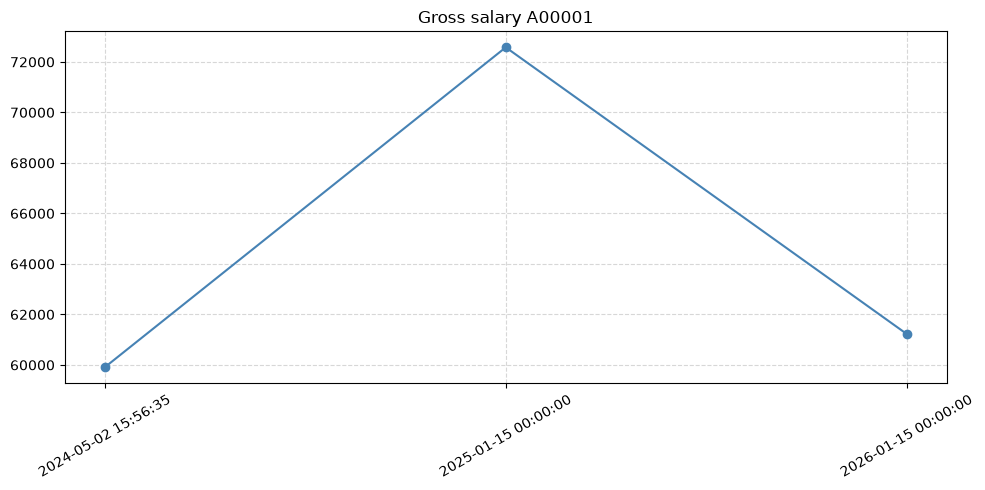

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(agent_df['declaration_date'], agent_df['gross_salary'], marker='o', color='steelblue')
ax.set_title('Gross salary ' + agent_id)
ax.tick_params(axis='x', rotation=30); ax.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout(); plt.show()


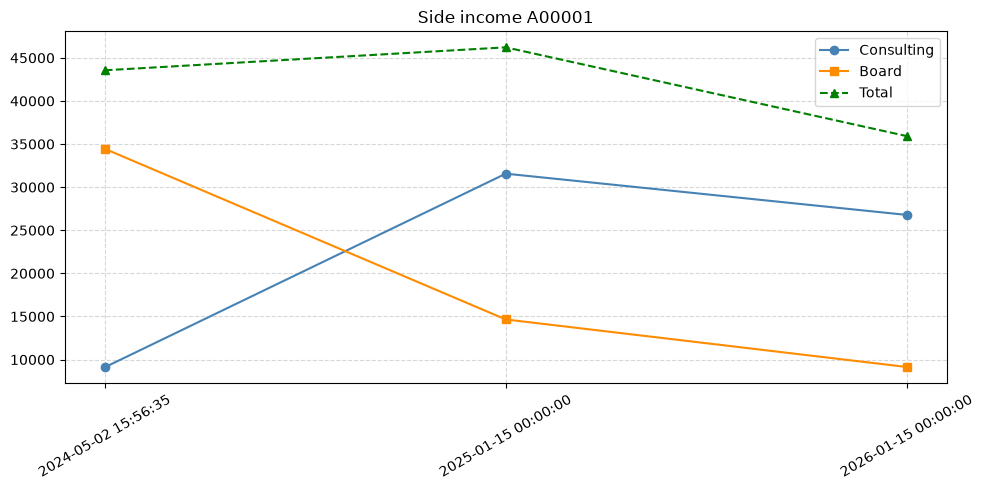

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(agent_df['declaration_date'], agent_df['side_income_consulting'], marker='o', color='steelblue', label='Consulting')
ax.plot(agent_df['declaration_date'], agent_df['side_income_board_memberships'], marker='s', color='darkorange', label='Board')
total_side = agent_df['side_income_consulting'] + agent_df['side_income_board_memberships']
ax.plot(agent_df['declaration_date'], total_side, marker='^', color='green', linestyle='--', label='Total')
ax.set_title('Side income ' + agent_id)
ax.legend(); ax.tick_params(axis='x', rotation=30); ax.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout(); plt.show()


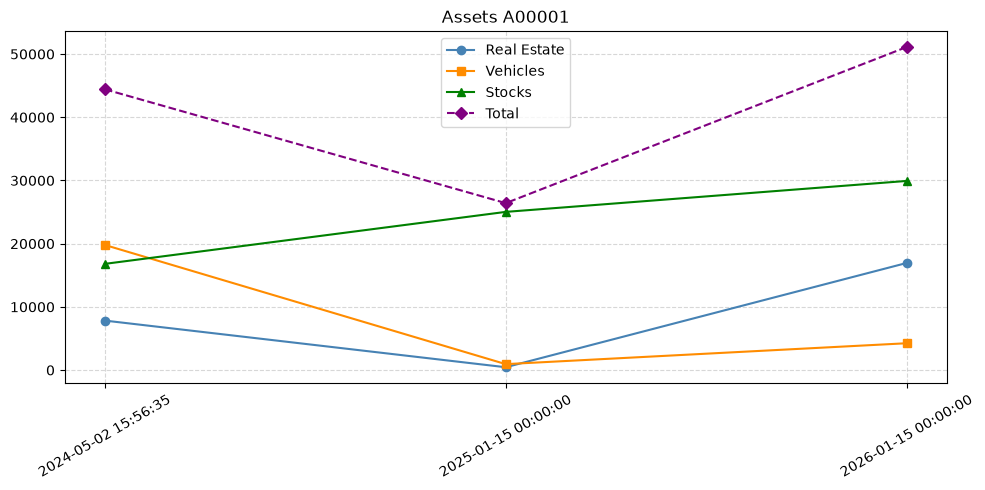

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(agent_df['declaration_date'], agent_df['assets_in_real_estate'], marker='o', color='steelblue', label='Real Estate')
ax.plot(agent_df['declaration_date'], agent_df['assets_in_vehicles'], marker='s', color='darkorange', label='Vehicles')
ax.plot(agent_df['declaration_date'], agent_df['assets_in_stocks'], marker='^', color='green', label='Stocks')
total = agent_df['assets_in_real_estate'] + agent_df['assets_in_vehicles'] + agent_df['assets_in_stocks']
ax.plot(agent_df['declaration_date'], total, marker='D', color='purple', linestyle='--', label='Total')
ax.set_title('Assets ' + agent_id)
ax.legend(); ax.tick_params(axis='x', rotation=30); ax.grid(True, linestyle='--', alpha=0.5)
fig.tight_layout(); plt.show()


## US16 - Boxplot of total income by role

                  count           mean           std           min  \
role                                                                 
Advisor          1572.0  101270.070609  32854.224556  23846.452855   
Judge            8912.0   99711.464395  32127.130637  21908.337980   
MP               2360.0  101061.628178  32878.243106  26559.135827   
Minister          175.0   96156.687019  31015.852247  32553.213902   
State Secretary   376.0  100297.595548  33447.626433  23350.010876   

                          25%           50%            75%            max  
role                                                                       
Advisor          79122.161882  96513.303737  118802.403298  254287.574802  
Judge            77199.419734  94857.932011  116453.327861  275510.227416  
MP               78556.452782  96782.073148  118637.576710  332624.203108  
Minister         74221.187375  95311.962674  111907.254236  259848.690024  
State Secretary  77431.620086  95452.290326  117786.8

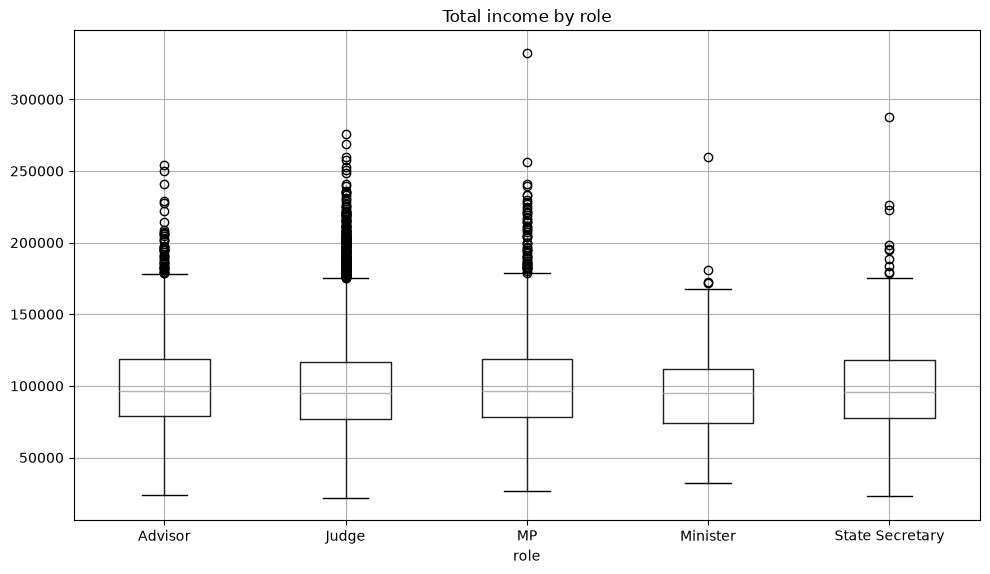

In [17]:
df16 = pd.read_csv(DATASET_DECLARATIONS)
df16['total_income'] = df16['gross_salary'] + df16['side_income_consulting'] + df16['side_income_board_memberships']
print(df16.groupby('role')['total_income'].describe())
fig, ax = plt.subplots(figsize=(10, 6))
df16.boxplot(column='total_income', by='role', ax=ax)
ax.set_title('Total income by role'); plt.suptitle('')
fig.tight_layout(); plt.show()


## US17 - Top 10 companies by total share value

Top 10:
  100000040.0 1255171.54
  100000007.0 1055356.04
  100000027.0 967763.75
  100000031.0 921632.71
  100000062.0 887180.43
  100000033.0 857075.05
  100000069.0 821211.52
  100000084.0 817628.3
  100000064.0 789040.29
  100000028.0 768361.76


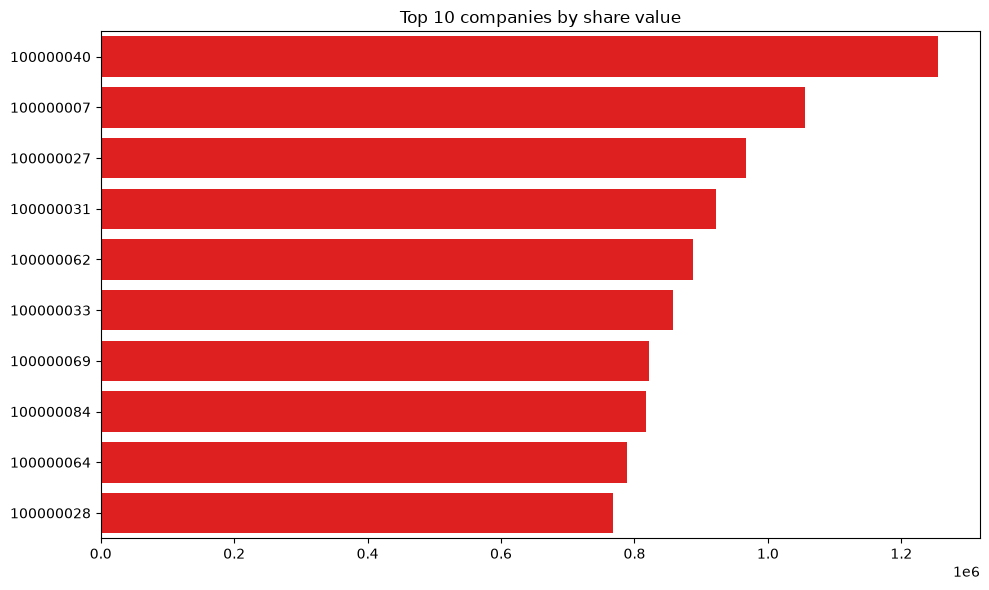

In [18]:
df17 = pd.read_csv(DATASET_HOLDINGS)
df17 = df17.sort_values('declaration_date').drop_duplicates(subset=['agent_id', 'company_NIF'], keep='last')
agg = df17.groupby('company_NIF', as_index=False)['total_value_in_stocks'].sum()
agg = agg.sort_values('total_value_in_stocks', ascending=False)
top10 = agg.head(10)
print('Top 10:')
for _, row in top10.iterrows():
    print(' ', row['company_NIF'], round(row['total_value_in_stocks'], 2))
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top10['total_value_in_stocks'].tolist(), y=[str(n) for n in top10['company_NIF']], color='red', ax=ax)
ax.set_title('Top 10 companies by share value')
fig.tight_layout(); plt.show()


## US18 - Top 10 stock value increases

Top 10 increases:
  A00049 100000096 295755.53
  A00054 100000048 294409.12
  A00074 100000084 280404.72
  A00095 100000055 274581.66
  A00051 100000080 269916.52
  A00092 100000073 255185.21
  A00059 100000037 238901.29
  A00036 100000071 236673.66
  A00068 100000000 234024.35
  A00006 100000003 232306.78


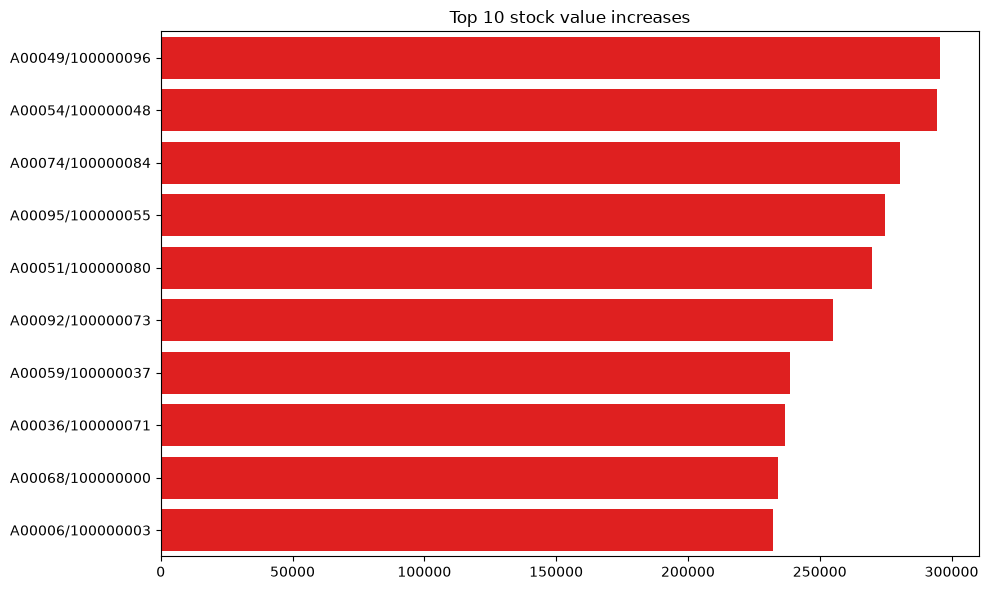

In [19]:
df18 = pd.read_csv(DATASET_HOLDINGS)
df18['declaration_date'] = pd.to_datetime(df18['declaration_date'])
rows = []
for (agent_id, nif), group in df18.groupby(['agent_id', 'company_NIF']):
    if len(group) < 2: continue
    g = group.sort_values('declaration_date')
    initial = g['total_value_in_stocks'].values[0]
    latest = g['total_value_in_stocks'].values[-1]
    rows.append({'agent_id': agent_id, 'company_NIF': nif,
                 'initial_value': initial, 'latest_value': latest,
                 'increase': latest - initial})
df_inc = pd.DataFrame(rows).sort_values('increase', ascending=False)
top10_inc = df_inc.head(10)
print('Top 10 increases:')
for _, row in top10_inc.iterrows():
    print(' ', row['agent_id'], row['company_NIF'], round(row['increase'], 2))

labels = [str(r['agent_id']) + '/' + str(r['company_NIF']) for _, r in top10_inc.iterrows()]
fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(x=top10_inc['increase'].tolist(), y=labels, color='red', ax=ax)
ax.set_title('Top 10 stock value increases')
fig.tight_layout(); plt.show()


### Stock value evolution over time (top 10 agent/company pairs)

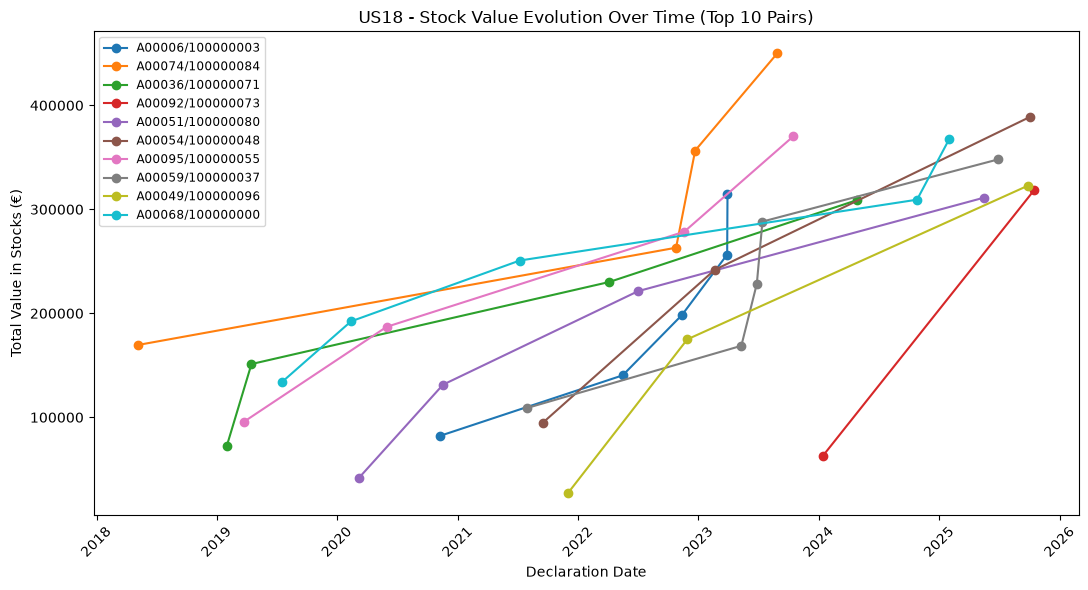

In [20]:
pairs = set(zip(top10_inc['agent_id'], top10_inc['company_NIF']))
mask = [(a, c) in pairs for a, c in df18[['agent_id', 'company_NIF']].values]
df_evol = df18[mask]

fig, ax = plt.subplots(figsize=(11, 6))
for agent_id, company_nif in pairs:
    sub = df_evol[(df_evol['agent_id'] == agent_id) & (df_evol['company_NIF'] == company_nif)]
    sub = sub.sort_values('declaration_date')
    ax.plot(sub['declaration_date'], sub['total_value_in_stocks'],
            marker='o', label=str(agent_id) + '/' + str(company_nif))
ax.set_title('US18 - Stock Value Evolution Over Time (Top 10 Pairs)')
ax.set_xlabel('Declaration Date')
ax.set_ylabel('Total Value in Stocks (\u20ac)')
ax.legend(loc='best', fontsize='small')
ax.tick_params(axis='x', rotation=45)
fig.tight_layout(); plt.show()


## US28 - Remuneration vs Asset Correlation (by role)

For a given role, Pearson's *r* between the total declared remuneration
(gross salary + side income) and each asset type (real estate, vehicles,
stocks), computed on each agent's first and last declaration so the two can be
compared (Statistics ch. 6).

In [21]:
ROLE = 'MP'

df28 = pd.read_csv(DATASET_DECLARATIONS)
df28['declaration_date'] = pd.to_datetime(df28['declaration_date'])
df28['total_remuneration'] = (df28['gross_salary']
                              + df28['side_income_consulting']
                              + df28['side_income_board_memberships'])
df28['total_assets'] = (df28['assets_in_real_estate']
                        + df28['assets_in_vehicles']
                        + df28['assets_in_stocks'])
df28 = df28[df28['role'] == ROLE]

asset_columns = {
    'Real Estate': 'assets_in_real_estate',
    'Vehicles': 'assets_in_vehicles',
    'Stocks': 'assets_in_stocks',
}

def interpret_correlation(r):
    a = abs(r)
    if a >= 0.8:
        return 'strong'
    if a >= 0.5:
        return 'moderate'
    if a >= 0.1:
        return 'weak'
    return 'negligible'

df_first = df28.sort_values('declaration_date').drop_duplicates(subset='agent_id', keep='first')
df_last = df28.sort_values('declaration_date').drop_duplicates(subset='agent_id', keep='last')

rows = []
for label, col in asset_columns.items():
    fit_first = stats.linregress(df_first['total_remuneration'], df_first[col])
    fit_last = stats.linregress(df_last['total_remuneration'], df_last[col])
    rows.append({
        'asset': label,
        'r (first)': round(fit_first.rvalue, 4),
        'p (first)': round(fit_first.pvalue, 4),
        'r (last)': round(fit_last.rvalue, 4),
        'p (last)': round(fit_last.pvalue, 4),
        'interpretation (last)': interpret_correlation(fit_last.rvalue),
    })
table28 = pd.DataFrame(rows).set_index('asset')
print('role:', ROLE, '| agents (first):', len(df_first), '| agents (last):', len(df_last))
overall = stats.linregress(df_last['total_remuneration'], df_last['total_assets'])
print(f'overall (last) remuneration vs TOTAL assets: r={overall.rvalue:.4f}  p={overall.pvalue:.4f}')
table28

role: MP | agents (first): 345 | agents (last): 345
overall (last) remuneration vs TOTAL assets: r=0.0822  p=0.1275


,r (first),p (first),r (last),p (last),interpretation (last)
asset,,,,,
Real Estate,0.0470,0.3838,-0.0234,0.6649,negligible
Vehicles,0.0658,0.2229,0.1235,0.0217,weak
Stocks,0.0356,0.5096,0.0314,0.5609,negligible


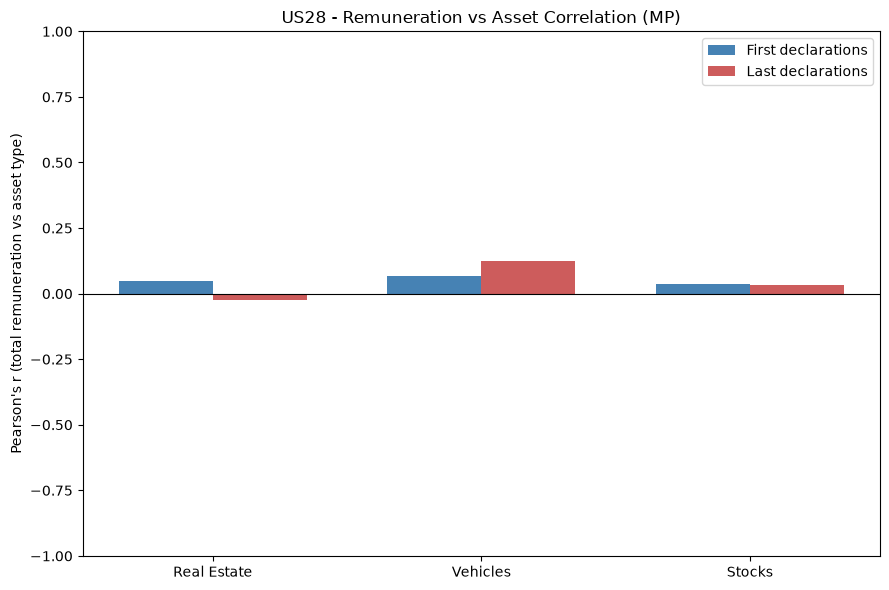

In [22]:
labels = list(asset_columns.keys())
first_values = [table28.loc[l, 'r (first)'] for l in labels]
last_values = [table28.loc[l, 'r (last)'] for l in labels]
pos = range(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
ax.bar([p - width / 2 for p in pos], first_values, width, label='First declarations', color='steelblue')
ax.bar([p + width / 2 for p in pos], last_values, width, label='Last declarations', color='indianred')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_xticks(list(pos))
ax.set_xticklabels(labels)
ax.set_ylabel("Pearson's r (total remuneration vs asset type)")
ax.set_ylim(-1, 1)
ax.set_title(f'US28 - Remuneration vs Asset Correlation ({ROLE})')
ax.legend()
plt.tight_layout()
plt.show()

## US29 - Detection of Unusual Wealth Accumulation

Flags political agents whose declared wealth deviates strongly from what their
income predicts. A linear regression `total_assets ~ total_income` is fitted on
each agent's most recent declaration; agents are ranked by the absolute
regression residual and those whose residual has a |z-score| above 2 are
reported as outliers (Statistics ch. 6/7).

Regression: assets = 0.0283 * income + 56546.27
r = 0.0261  r2 = 0.0007

Top 10 agents by deviation:
  A01034     residual=    182,974.35
  A00236     residual=    180,503.20
  A01884     residual=    177,903.26
  A00070     residual=    175,290.90
  A02341     residual=    170,810.40
  A01300     residual=    163,045.52
  A01715     residual=    158,911.41
  A01000     residual=    157,125.16
  A00431     residual=    143,903.16
  A00833     residual=    142,181.83

Outliers (|z| > 2): 101


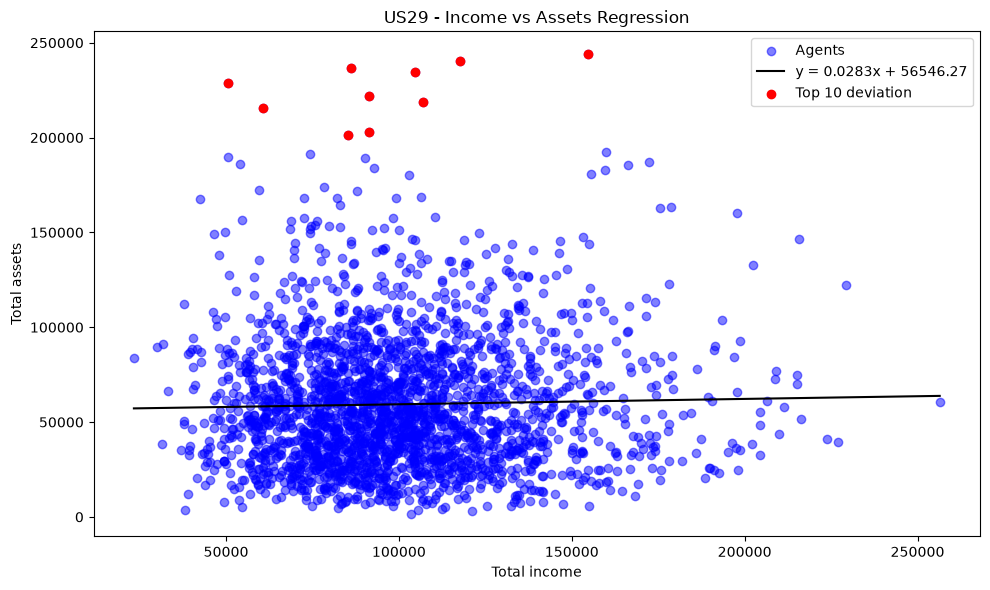

In [23]:
df29 = pd.read_csv(DATASET_DECLARATIONS)
df29 = df29.sort_values('declaration_date').drop_duplicates(subset='agent_id', keep='last')
df29['total_income'] = (df29['gross_salary']
                        + df29['side_income_consulting']
                        + df29['side_income_board_memberships'])
df29['total_assets'] = (df29['assets_in_real_estate']
                        + df29['assets_in_vehicles']
                        + df29['assets_in_stocks'])

fit29 = stats.linregress(df29['total_income'], df29['total_assets'])
print(f'Regression: assets = {fit29.slope:.4f} * income + {fit29.intercept:.2f}')
print(f'r = {fit29.rvalue:.4f}  r2 = {fit29.rvalue**2:.4f}')

df29['predicted_assets'] = fit29.slope * df29['total_income'] + fit29.intercept
df29['residual'] = df29['total_assets'] - df29['predicted_assets']
df29['abs_residual'] = df29['residual'].abs()
top29 = df29.sort_values('abs_residual', ascending=False).head(10)

std_r = df29['residual'].std()
df29['z_score'] = (df29['residual'] - df29['residual'].mean()) / std_r
outliers29 = df29[df29['z_score'].abs() > 2.0]

print(f'\nTop {len(top29)} agents by deviation:')
for _, row in top29.iterrows():
    print(f"  {str(row['agent_id']):<10} residual={row['residual']:>14,.2f}")
print(f'\nOutliers (|z| > 2): {len(outliers29)}')

plt.figure(figsize=(10, 6))
plt.scatter(df29['total_income'], df29['total_assets'], color='blue', alpha=0.5, label='Agents')
x_line = np.linspace(df29['total_income'].min(), df29['total_income'].max(), 100)
plt.plot(x_line, fit29.slope * x_line + fit29.intercept, color='black',
         label=f'y = {fit29.slope:.4f}x + {fit29.intercept:.2f}')
plt.scatter(top29['total_income'], top29['total_assets'], color='red', label='Top 10 deviation')
plt.title('US29 - Income vs Assets Regression')
plt.xlabel('Total income')
plt.ylabel('Total assets')
plt.legend()
plt.tight_layout()
plt.show()

## US30 - Residual Analysis of the Income -> Assets Regression

Fits the linear regression total_assets ~ total_income on each agent's most
recent declaration, computes the residuals e_i = y_i - (slope*x_i + intercept)
and inspects their distribution against a Normal with the same mean and standard
deviation (Normality assumption of linear regression, ch. 6). This validates the
"agents with greatest deviation" of US29.

In [24]:
df30 = pd.read_csv(DATASET_DECLARATIONS)
df30['declaration_date'] = pd.to_datetime(df30['declaration_date'])
df30 = df30.sort_values('declaration_date').drop_duplicates(subset='agent_id', keep='last')
df30['total_income'] = (df30['gross_salary']
                        + df30['side_income_consulting']
                        + df30['side_income_board_memberships'])
df30['total_assets'] = (df30['assets_in_real_estate']
                        + df30['assets_in_vehicles']
                        + df30['assets_in_stocks'])

model = stats.linregress(df30['total_income'], df30['total_assets'])
res_original = df30['total_assets'] - (model.slope * df30['total_income'] + model.intercept)
res_normalized = (res_original - res_original.mean()) / res_original.std()

print(f'regression: assets = {model.slope:.4f} * income + {model.intercept:,.2f}')
print(f'r = {model.rvalue:.4f}    r^2 = {model.rvalue ** 2:.4f}')

n = len(res_original)
print('\nValidity check (observed vs Normal-expected beyond +/- k sigma):')
for k in (2.0, 3.0):
    obs = int((res_normalized.abs() > k).sum())
    exp = n * 2 * (1 - stats.norm.cdf(k))
    print(f'  |z| > {k:.0f}: observed = {obs:4d} ({obs / n:6.2%})   Normal-expected = {exp:6.1f} ({exp / n:6.2%})')

pd.DataFrame({'original': res_original.describe(), 'normalized (z-score)': res_normalized.describe()})

regression: assets = 0.0283 * income + 56,546.27
r = 0.0261    r^2 = 0.0007

Validity check (observed vs Normal-expected beyond +/- k sigma):
  |z| > 2: observed =  101 ( 4.27%)   Normal-expected =  107.6 ( 4.55%)
  |z| > 3: observed =   30 ( 1.27%)   Normal-expected =    6.4 ( 0.27%)


,original,normalized (z-score)
count,2.364000e+03,2.364000e+03
mean,8.371660e-13,1.953692e-17
std,3.447586e+04,1.000000e+00
min,-5.770642e+04,-1.673821e+00
25%,-2.515840e+04,-7.297397e-01
50%,-5.790139e+03,-1.679476e-01
75%,1.830548e+04,5.309652e-01
max,1.829744e+05,5.307319e+00


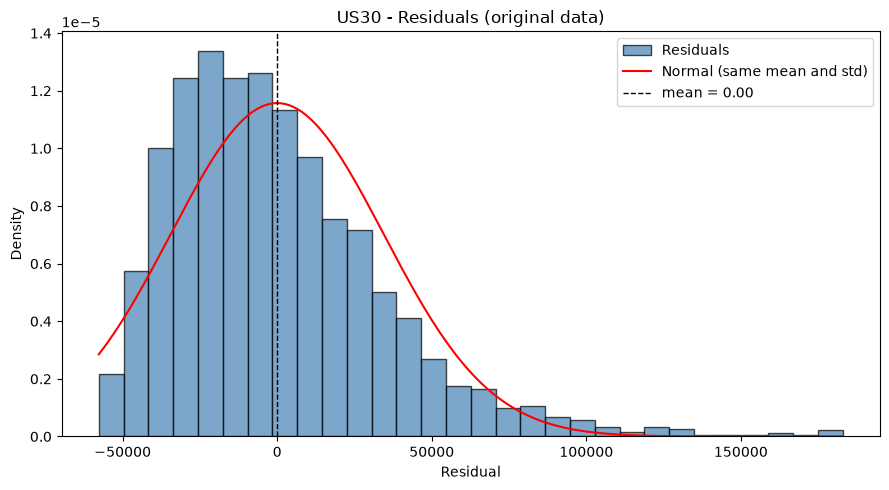

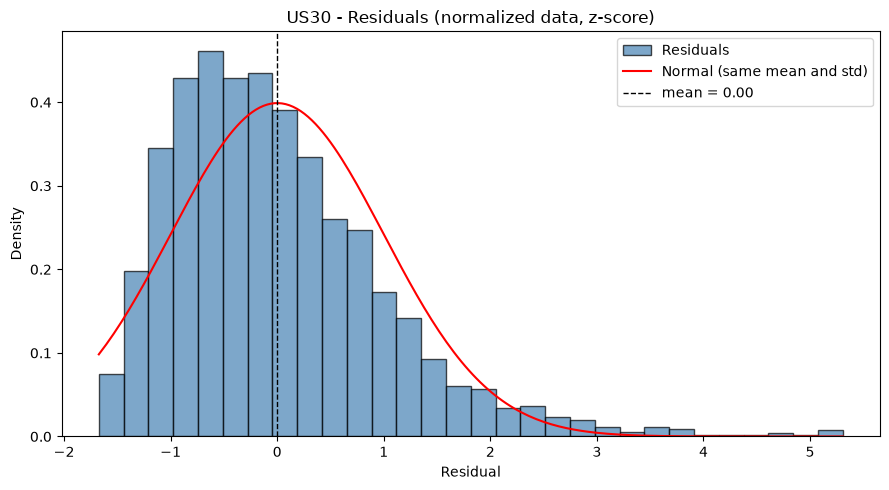

In [25]:
for residuals, title in [(res_original, 'US30 - Residuals (original data)'),
                         (res_normalized, 'US30 - Residuals (normalized data, z-score)')]:
    mean = residuals.mean()
    std = residuals.std()
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(residuals, bins=30, density=True, color='steelblue', edgecolor='black', alpha=0.7, label='Residuals')
    if std > 0:
        xs = np.linspace(residuals.min(), residuals.max(), 200)
        ax.plot(xs, stats.norm.pdf(xs, mean, std), 'r-', label='Normal (same mean and std)')
    ax.axvline(mean, color='black', linestyle='--', linewidth=1, label=f'mean = {mean:.2f}')
    ax.set_title(title)
    ax.set_xlabel('Residual')
    ax.set_ylabel('Density')
    ax.legend()
    plt.tight_layout()
    plt.show()

## US31 - Shareholding % vs Stock Value (linearity check)

Investigates whether the relationship between the shareholding percentage and
the total declared stock value is linear or accelerates at higher ownership
levels. Uses a least-squares linear fit + r^2 and a segmented (equal-width)
analysis by ownership level (ch. 6). Most recent declaration of each
agent/company pair only.

In [26]:
df31 = pd.read_csv(DATASET_HOLDINGS)
df31['declaration_date'] = pd.to_datetime(df31['declaration_date'])
df31 = df31.sort_values('declaration_date').drop_duplicates(subset=['agent_id', 'company_NIF'], keep='last')

model31 = stats.linregress(df31['company_percentage'], df31['total_value_in_stocks'])
print('LINEAR FIT (value ~ percentage)')
print(f'  line : value = {model31.slope:,.2f} * percentage + {model31.intercept:,.2f}')
print(f'  r    = {model31.rvalue:.4f}    r^2 = {model31.rvalue ** 2:.4f}')

df31['segment'] = pd.cut(df31['company_percentage'], bins=5)
rows = []
for segment, group in df31.groupby('segment', observed=True):
    if len(group) >= 2:
        seg_fit = stats.linregress(group['company_percentage'], group['total_value_in_stocks'])
        seg_slope = round(seg_fit.slope, 2)
    else:
        seg_slope = float('nan')
    rows.append({
        'range': f'[{segment.left:.2f}%, {segment.right:.2f}%]',
        'n': len(group),
        'mean_value': round(group['total_value_in_stocks'].mean(), 2),
        'slope': seg_slope,
    })
seg_table = pd.DataFrame(rows).set_index('range')
seg_table

LINEAR FIT (value ~ percentage)
  line : value = 1,768.46 * percentage + 110,491.36
  r    = 0.1434    r^2 = 0.0206


,n,mean_value,slope
range,,,
"[0.75%, 5.60%]",56,113365.89,7569.30
"[5.60%, 10.43%]",60,138712.89,-7070.74
"[10.43%, 15.26%]",48,115657.53,7095.73
"[15.26%, 20.09%]",45,145573.56,-938.49
"[20.09%, 24.92%]",58,150855.32,11857.36


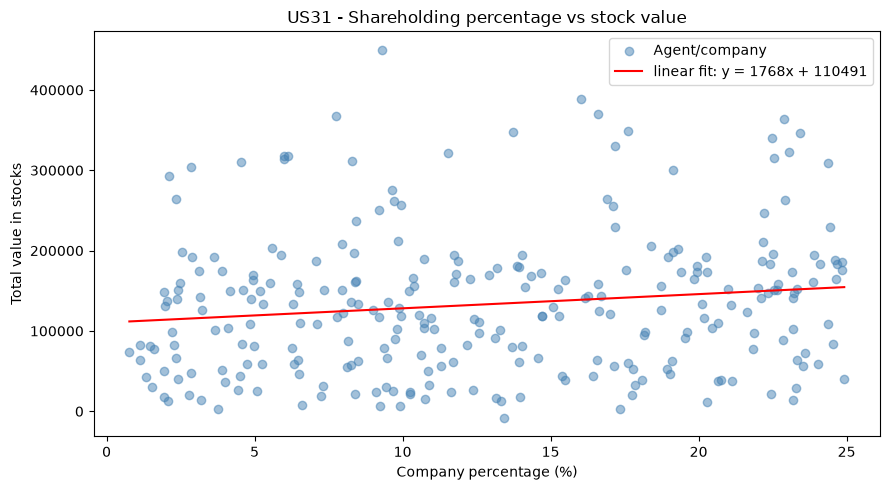

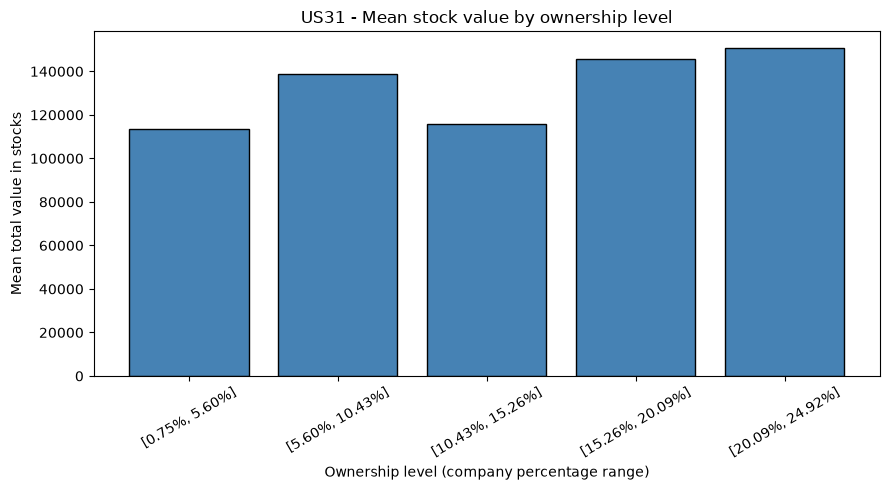

In [27]:
x = df31['company_percentage']
y = df31['total_value_in_stocks']

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(x, y, color='steelblue', alpha=0.5, label='Agent/company')
lx = np.linspace(x.min(), x.max(), 100)
ax.plot(lx, model31.slope * lx + model31.intercept, color='red',
        label=f'linear fit: y = {model31.slope:.0f}x + {model31.intercept:.0f}')
ax.set_title('US31 - Shareholding percentage vs stock value')
ax.set_xlabel('Company percentage (%)')
ax.set_ylabel('Total value in stocks')
ax.legend()
plt.tight_layout()
plt.show()

labels31 = list(seg_table.index)
means31 = list(seg_table['mean_value'])
fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(labels31, means31, color='steelblue', edgecolor='black')
ax.set_title('US31 - Mean stock value by ownership level')
ax.set_xlabel('Ownership level (company percentage range)')
ax.set_ylabel('Mean total value in stocks')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()